# Sales Funnel Analysis

## Project Goal

The purpose of this notebook is to analyze the e-commerce sales funnel and identify where users leave the purchasing process.

The analysis focuses on user progression through the three key stages:

- Product View
- Add to Cart
- Purchase

Additionally, the notebook compares conversion rates across product categories and brands to identify the strongest and weakest performing segments.

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

events = pd.read_csv(file_path1)
products = pd.read_csv(file_path2)

events["event_time"] = pd.to_datetime(events["event_time"])

df = events.merge(
    products,
    on="product_id",
    how="left"
)

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,event_time,event_type,product_id,user_id,user_session,category_id,category_code,brand,price
0,2019-11-01 13:06:48+00:00,view,1801539,513862142,73e0d0ba-31ac-4969-99b6-99384c7befd5,2053013554415534427,electronics.video.tv,lg,406.70
1,2019-11-01 14:54:06+00:00,view,1004795,529291197,e41aa5ae-cdd3-4028-aafe-2a223a78993a,2053013555631882655,electronics.smartphone,xiaomi,218.54
2,2019-11-01 14:34:54+00:00,view,14701260,543844376,a4adcef6-80d7-44d5-8e6b-deb3799ae13f,2053013557133443581,furniture.living_room.cabinet,NaN,174.78
3,2019-11-01 13:08:57+00:00,view,14700105,534177598,8ca640b8-7cab-41d2-a7d5-b0335a675ca5,2053013557133443581,furniture.living_room.cabinet,NaN,385.85
4,2019-11-01 11:27:41+00:00,view,1004965,520248589,04acae74-f5a9-4407-bca3-740e3263a1c0,2053013555631882655,electronics.smartphone,oppo,900.87


## Event Types

Before building the funnel, we first examine the distribution of event types available in the dataset.

In [6]:
df["event_type"].value_counts()

,count
event_type,
view,483943
purchase,8746
cart,7311


#### Observation

The dataset consists primarily of product views, followed by cart additions and purchases. This confirms that the data contains all stages required for funnel analysis.

## Funnel Based on Events

This section measures the number of events at each stage of the purchasing funnel.

In [7]:
funnel_events = (
    df[df["event_type"].isin(["view", "cart", "purchase"])]
    .groupby("event_type")
    .size()
    .reindex(["view", "cart", "purchase"])
    .reset_index(name="events")
)

funnel_events

,event_type,events
0,view,483943
1,cart,7311
2,purchase,8746


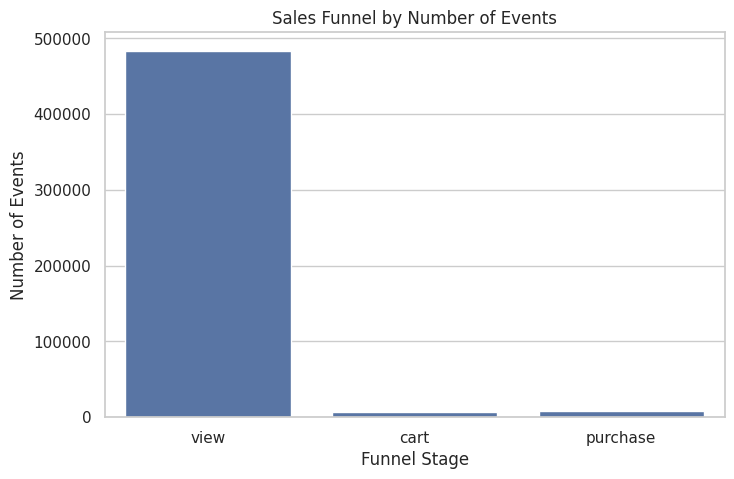

In [8]:
plt.figure(figsize=(8, 5))
sns.barplot(data=funnel_events, x="event_type", y="events")

plt.title("Sales Funnel by Number of Events")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Events")
plt.show()

#### Observation

The number of events decreases substantially from product views to purchases, illustrating the natural narrowing of the sales funnel.

## Funnel Based on Unique Users

Instead of counting events, this analysis measures how many unique users reach each stage of the funnel.

In [9]:
funnel_users = (
    df[df["event_type"].isin(["view", "cart", "purchase"])]
    .groupby("event_type")["user_id"]
    .nunique()
    .reindex(["view", "cart", "purchase"])
    .reset_index(name="users")
)

funnel_users

,event_type,users
0,view,137213
1,cart,5121
2,purchase,7324


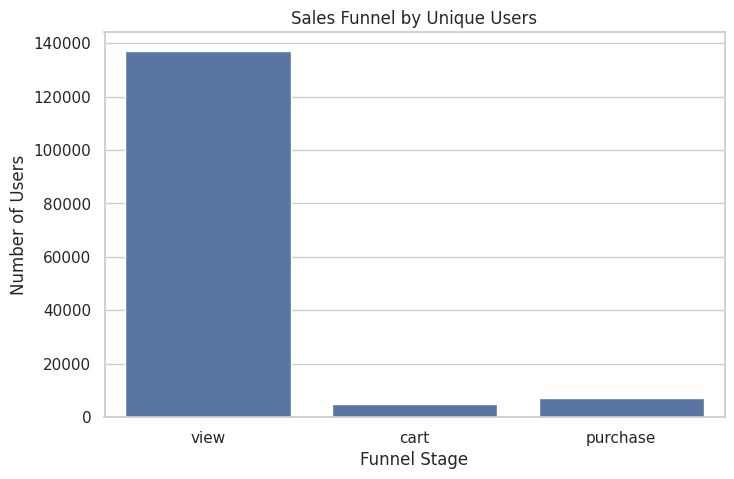

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(data=funnel_users, x="event_type", y="users")

plt.title("Sales Funnel by Unique Users")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Users")
plt.show()

#### Observation

The user-based funnel provides a clearer picture of customer progression by removing repeated actions from the same user.

## Conversion Rates

Conversion rates quantify the percentage of users progressing from one funnel stage to the next.

In [11]:
views = funnel_users.loc[funnel_users["event_type"] == "view", "users"].iloc[0]
carts = funnel_users.loc[funnel_users["event_type"] == "cart", "users"].iloc[0]
purchases = funnel_users.loc[funnel_users["event_type"] == "purchase", "users"].iloc[0]

view_to_cart = carts / views * 100
cart_to_purchase = purchases / carts * 100
view_to_purchase = purchases / views * 100

conversion_rates = pd.DataFrame({
    "metric": [
        "View to Cart",
        "Cart to Purchase",
        "View to Purchase"
    ],
    "conversion_rate": [
        view_to_cart,
        cart_to_purchase,
        view_to_purchase
    ]
})

conversion_rates["conversion_rate"] = conversion_rates["conversion_rate"].round(2)

conversion_rates

,metric,conversion_rate
0,View to Cart,3.73
1,Cart to Purchase,143.02
2,View to Purchase,5.34


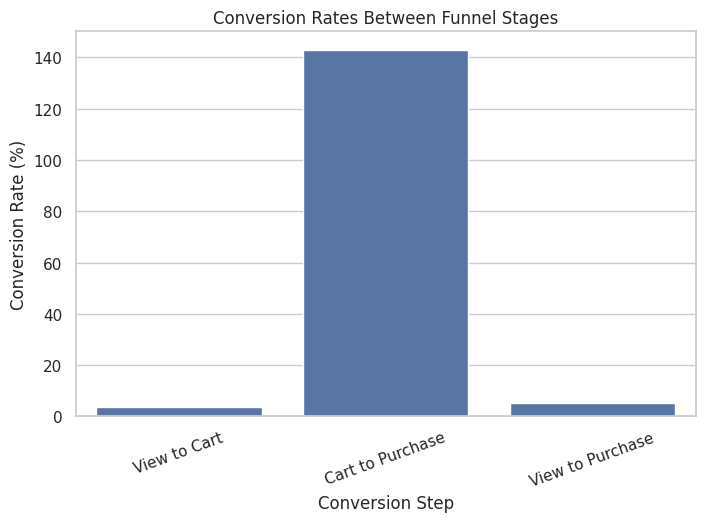

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(data=conversion_rates, x="metric", y="conversion_rate")

plt.title("Conversion Rates Between Funnel Stages")
plt.xlabel("Conversion Step")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=20)
plt.show()

#### Observation

The View → Cart conversion is considerably lower than the Cart → Purchase conversion, suggesting that the largest loss occurs at the beginning of the customer journey.

## Drop-off Analysis

In [13]:
dropoff_rates = pd.DataFrame({
    "stage": [
        "View → Cart",
        "Cart → Purchase"
    ],
    "dropoff_rate": [
        100 - view_to_cart,
        100 - cart_to_purchase
    ]
})

dropoff_rates["dropoff_rate"] = dropoff_rates["dropoff_rate"].round(2)

dropoff_rates

,stage,dropoff_rate
0,View → Cart,96.27
1,Cart → Purchase,-43.02


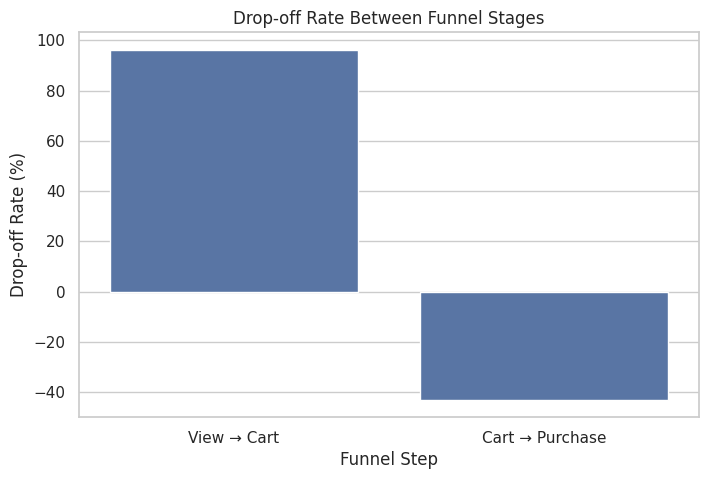

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(data=dropoff_rates, x="stage", y="dropoff_rate")

plt.title("Drop-off Rate Between Funnel Stages")
plt.xlabel("Funnel Step")
plt.ylabel("Drop-off Rate (%)")
plt.show()

#### Observation

The highest drop-off rate identifies the stage where the greatest number of potential customers abandon the purchasing process.

# Category Performance

This section compares conversion rates across product categories.

In [15]:
category_funnel = (
    df[df["event_type"].isin(["view", "cart", "purchase"])]
    .groupby(["category_code", "event_type"])["user_id"]
    .nunique()
    .unstack(fill_value=0)
)

category_funnel = category_funnel[["view", "cart", "purchase"]]

category_funnel["view_to_cart_%"] = (
    category_funnel["cart"] / category_funnel["view"] * 100
).round(2)

category_funnel["cart_to_purchase_%"] = (
    category_funnel["purchase"] / category_funnel["cart"] * 100
).replace([np.inf, -np.inf], np.nan).round(2)

category_funnel["view_to_purchase_%"] = (
    category_funnel["purchase"] / category_funnel["view"] * 100
).round(2)

category_funnel = category_funnel.reset_index()

category_funnel.head()

event_type,category_code,view,cart,purchase,view_to_cart_%,cart_to_purchase_%,view_to_purchase_%
0,accessories.bag,831,1,7,0.12,700.0,0.84
1,accessories.umbrella,31,0,0,0.00,NaN,0.00
2,accessories.wallet,176,0,6,0.00,NaN,3.41
3,apparel.belt,16,0,1,0.00,NaN,6.25
4,apparel.costume,1260,0,4,0.00,NaN,0.32


In [16]:
top_category_conversion = (
    category_funnel[category_funnel["view"] >= 100]
    .sort_values("view_to_purchase_%", ascending=False)
    .head(10)
)

top_category_conversion

event_type,category_code,view,cart,purchase,view_to_cart_%,cart_to_purchase_%,view_to_purchase_%
94,electronics.smartphone,46047,3485,3391,7.57,97.30,7.36
28,appliances.iron,610,2,36,0.33,1800.00,5.90
40,appliances.kitchen.microwave,767,17,44,2.22,258.82,5.74
49,appliances.personal.scales,271,3,15,1.11,500.00,5.54
87,electronics.audio.headphone,5887,301,317,5.11,105.32,5.38
45,appliances.kitchen.toster,102,0,5,0.00,NaN,4.90
74,construction.components.faucet,104,1,5,0.96,500.00,4.81
24,appliances.environment.air_heater,271,5,13,1.85,260.00,4.80
29,appliances.ironing_board,147,1,7,0.68,700.00,4.76
47,appliances.personal.hair_cutter,239,1,11,0.42,1100.00,4.60


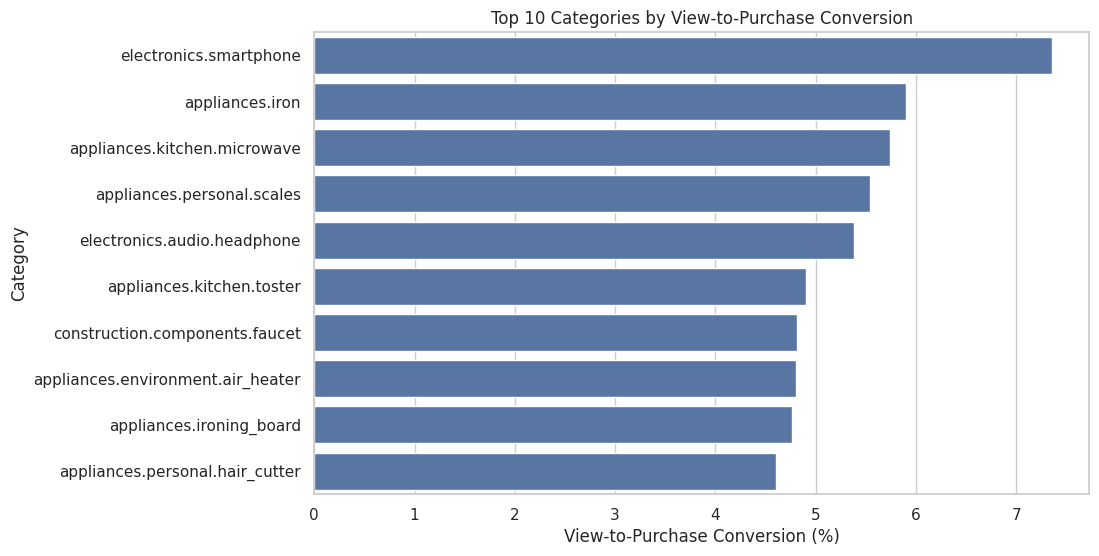

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_category_conversion,
    y="category_code",
    x="view_to_purchase_%"
)

plt.title("Top 10 Categories by View-to-Purchase Conversion")
plt.xlabel("View-to-Purchase Conversion (%)")
plt.ylabel("Category")
plt.show()

In [18]:
category_dropoff = (
    category_funnel[category_funnel["view"] >= 100]
    .sort_values("view_to_purchase_%", ascending=True)
    .head(10)
)

category_dropoff

event_type,category_code,view,cart,purchase,view_to_cart_%,cart_to_purchase_%,view_to_purchase_%
20,apparel.trousers,156,0,0,0.00,NaN,0.00
79,construction.tools.pump,120,0,0,0.00,NaN,0.00
77,construction.tools.light,114,0,0,0.00,NaN,0.00
5,apparel.dress,424,0,1,0.00,NaN,0.24
4,apparel.costume,1260,0,4,0.00,NaN,0.32
117,sport.bicycle,469,1,2,0.21,200.0,0.43
121,sport.trainer,225,0,1,0.00,NaN,0.44
22,apparel.underwear,207,0,1,0.00,NaN,0.48
6,apparel.jeans,399,0,2,0.00,NaN,0.50
9,apparel.shirt,186,0,1,0.00,NaN,0.54


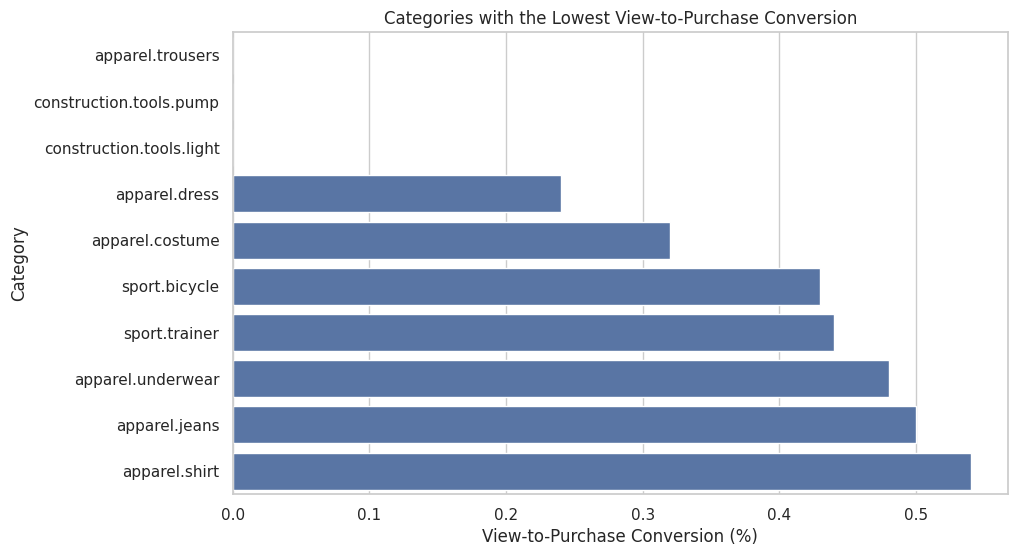

In [19]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=category_dropoff,
    y="category_code",
    x="view_to_purchase_%"
)

plt.title("Categories with the Lowest View-to-Purchase Conversion")
plt.xlabel("View-to-Purchase Conversion (%)")
plt.ylabel("Category")
plt.show()

In [20]:
brand_funnel = (
    df[df["event_type"].isin(["view", "cart", "purchase"])]
    .dropna(subset=["brand"])
    .groupby(["brand", "event_type"])["user_id"]
    .nunique()
    .unstack(fill_value=0)
)

brand_funnel = brand_funnel[["view", "cart", "purchase"]]

brand_funnel["view_to_cart_%"] = (
    brand_funnel["cart"] / brand_funnel["view"] * 100
).round(2)

brand_funnel["cart_to_purchase_%"] = (
    brand_funnel["purchase"] / brand_funnel["cart"] * 100
).replace([np.inf, -np.inf], np.nan).round(2)

brand_funnel["view_to_purchase_%"] = (
    brand_funnel["purchase"] / brand_funnel["view"] * 100
).round(2)

brand_funnel = brand_funnel.reset_index()

brand_funnel.head()

event_type,brand,view,cart,purchase,view_to_cart_%,cart_to_purchase_%,view_to_purchase_%
0,a-case,60,0,0,0.0,NaN,0.0
1,a-derma,1,0,0,0.0,NaN,0.0
2,a-elita,1,0,0,0.0,NaN,0.0
3,a-mega,3,0,0,0.0,NaN,0.0
4,abtoys,5,0,0,0.0,NaN,0.0


In [21]:
top_brand_conversion = (
    brand_funnel[brand_funnel["view"] >= 100]
    .sort_values("view_to_purchase_%", ascending=False)
    .head(10)
)

top_brand_conversion

event_type,brand,view,cart,purchase,view_to_cart_%,cart_to_purchase_%,view_to_purchase_%
123,apple,22451,1439,1480,6.41,102.85,6.59
1943,samsung,27116,1746,1780,6.44,101.95,6.56
1607,nokian,1393,71,85,5.10,119.72,6.10
1637,oasis,149,0,9,0.00,NaN,6.04
1880,rivertoys,139,0,8,0.00,NaN,5.76
1273,lanvin,178,0,10,0.00,NaN,5.62
154,asel,164,0,9,0.00,NaN,5.49
1851,remington,202,2,11,0.99,550.00,5.45
1567,navien,112,4,6,3.57,150.00,5.36
1477,microlab,131,1,7,0.76,700.00,5.34


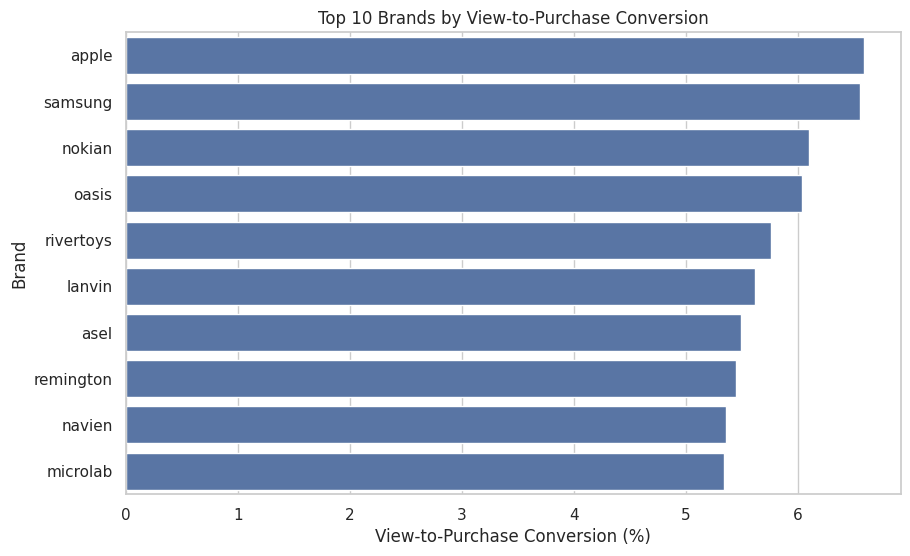

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_brand_conversion,
    y="brand",
    x="view_to_purchase_%"
)

plt.title("Top 10 Brands by View-to-Purchase Conversion")
plt.xlabel("View-to-Purchase Conversion (%)")
plt.ylabel("Brand")
plt.show()

# Key Findings

- Most users leave the funnel before adding products to the cart.
- The View → Cart stage represents the largest conversion loss.
- Cart → Purchase conversion is considerably stronger, indicating that purchase intent increases once users add items to their carts.
- Conversion performance differs across categories and brands.
- Several high-traffic categories generate relatively low purchase conversion, highlighting opportunities for optimization.